# build-raw-tissdiss-v2
Per-sample QC → concat → normalize → UMAP. All input files from `../../input/`.

In [1]:
import glob, re, os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scanpy.external as sce
from scipy.stats import median_abs_deviation

sc.settings.verbosity = 1

In [2]:
def is_outlier(adata, metric, nmads=5):
    M = adata.obs[metric]
    return (M < np.median(M) - nmads * median_abs_deviation(M)) | (M > np.median(M) + nmads * median_abs_deviation(M))

def extract_tis(fname):
    m = re.search(r'(TIS\d{5}-\d{3}(?:-\d{3})?)', fname)
    return m.group(1) if m else 'unknown'

def infer_project(fname):
    f = os.path.basename(fname).upper()
    if 'EXP00998' in f or 'EXP998' in f:   return 'aacr1'
    if 'EXP01109' in f and 'MULTIPLEX' in f: return 'aacr2-mp'
    if 'EXP01109' in f:                      return 'aacr2-sp'
    if 'EXP01349' in f and '_MP' in f:       return 'aacr3-mp'
    if 'EXP01349' in f:                      return 'aacr3-sp'
    if 'EXP01387' in f:                      return 'aacr4'
    return 'unknown'

In [3]:
from concurrent.futures import ThreadPoolExecutor

def process_sample(path):
    fname = os.path.basename(path)
    source_file = fname.replace('_sample_filtered_feature_bc_matrix.h5', '')
    tis_id      = extract_tis(fname)
    project     = infer_project(fname)

    adata = sc.read_10x_h5(path)
    adata.var_names_make_unique()
    adata.obs['source_file']      = source_file
    adata.obs['TIS_ID']           = tis_id
    adata.obs['project']          = project
    adata.obs['original_barcode'] = adata.obs.index.astype(str)

    n_raw = adata.n_obs

    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=[20], log1p=True, inplace=True)

    # if adata.n_obs >= 200:
    #     sc.pp.scrublet(adata, verbose=False)
    # else:
    #     adata.obs['doublet_score']     = 0.0
    #     adata.obs['predicted_doublet'] = False

    adata.obs['outlier'] = (
        is_outlier(adata, 'log1p_total_counts')
        | is_outlier(adata, 'log1p_n_genes_by_counts')
        | is_outlier(adata, 'pct_counts_in_top_20_genes')
    )

    n_outliers  = int(adata.obs['outlier'].sum())
    # n_doublets = int(adata.obs['predicted_doublet'].sum())
    # n_pass      = int((~adata.obs['predicted_doublet'] & ~adata.obs['outlier']).sum())

    record = {
        'source_file':        source_file,
        'TIS_ID':             tis_id,
        'project':            project,
        'n_cells_raw':        n_raw,
        'n_outliers_flagged': n_outliers,
        'median_n_genes':     int(np.median(adata.obs['n_genes_by_counts'])),
        'median_n_counts':    int(np.median(adata.obs['total_counts'])),
        'median_pct_mt':      round(float(np.median(adata.obs['pct_counts_mt'])), 2),
    }

    return adata, record

In [4]:
h5_files = sorted(glob.glob('../../input/**/*sample_filtered_feature_bc_matrix.h5', recursive=True))
print(f"Found {len(h5_files)} h5 files")

Found 93 h5 files


In [5]:
with ThreadPoolExecutor(max_workers=16) as ex:
    results = list(ex.map(process_sample, h5_files))

adata_list = [r[0] for r in results]
qc_records = [r[1] for r in results]

for rec in qc_records:
    print(f"{rec['source_file']}: {rec['n_cells_raw']} cells "
          f"({rec['n_outliers_flagged']} outliers flagged ")

qc_df = pd.DataFrame(qc_records)
print(f"\nTotal: {qc_df['n_cells_raw'].sum()} raw | {qc_df['n_outliers_flagged'].sum()} Outliers")

/home/workspace/spatial-pcd-data-release/.pixi/envs/default/lib/python3.14/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/workspace/spatial-pcd-data-release/.pixi/envs/default/lib/python3.14/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/workspace/spatial-pcd-data-release/.pixi/envs/default/lib/python3.14/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


EXP01109_Multiplex1_5_TIS05684_3: 13863 cells (50 outliers flagged 
Exp998_8_chronic_myleogenous_leukemia_TIS05398-001-008: 799 cells (16 outliers flagged 
EXP01387_3_TIS09206-001-001: 114 cells (4 outliers flagged 
EXP01109_Multiplex1_1_TIS06392_1: 9858 cells (12 outliers flagged 
EXP01109_TIS05681-001-004_c2: 12229 cells (110 outliers flagged 
EXP00942_New_CD_AR_TIS06615-001-002: 15703 cells (2097 outliers flagged 
Exp980_No_Stain1_TIS05841-001-008: 11406 cells (1225 outliers flagged 
EXP00904_w4_CD_AR_OldBlock_TIS06612-001-001: 2795 cells (290 outliers flagged 
Exp980_VIS_Stain1_TIS05841-001-008: 9091 cells (661 outliers flagged 
EXP00904_w3_Visium_OldBlock_TIS06612-001-001: 6870 cells (822 outliers flagged 
EXP01387_7_TIS09210-001-001: 3423 cells (127 outliers flagged 
EXP01109_Multiplex2_5_TIS05684_1: 8657 cells (46 outliers flagged 
EXP01109_TIS05681-001-004_c1: 13026 cells (148 outliers flagged 
EXP01109_Multiplex1_4_TIS05683_2: 14976 cells (387 outliers flagged 
EXP01109_Multip

In [6]:
qc_df.to_csv('files/qc-summary-v2.csv', index=False)
qc_df

,source_file,TIS_ID,project,n_cells_raw,n_outliers_flagged,median_n_genes,median_n_counts,median_pct_mt
0,EXP01109_Multiplex1_5_TIS05684_3,unknown,aacr2-mp,13863,50,1354,2120,1.21
1,Exp998_8_chronic_myleogenous_leukemia_TIS05398...,TIS05398-001-008,aacr1,799,16,73,73,1.92
2,EXP01387_3_TIS09206-001-001,TIS09206-001-001,aacr4,114,4,122,182,1.10
3,EXP01109_Multiplex1_1_TIS06392_1,unknown,aacr2-mp,9858,12,2141,3447,1.02
4,EXP01109_TIS05681-001-004_c2,TIS05681-001-004,aacr2-sp,12229,110,2338,4186,2.17
...,...,...,...,...,...,...,...,...
88,Exp00793_w8_AR_staining_TIS05740-001-001,TIS05740-001-001,unknown,7081,1223,3262,4149,1.05
89,EXP01109_Multiplex2_4_TIS05683_3,unknown,aacr2-mp,9355,215,1369,2975,1.71
90,Exp980_VIS_Stain2_TIS05841-001-008,TIS05841-001-008,unknown,7964,1052,1724,1953,1.53
91,Exp00793_w7_AR_staining_TIS05740-001-001,TIS05740-001-001,unknown,12591,1006,1704,2051,1.19


In [7]:
adata_merged = ad.concat(adata_list, join='outer')
adata_merged.var_names_make_unique()
adata_merged.obs_names_make_unique()

# save raw before any gene filtering
adata_merged.write('files/raw-all-tissdiss-v2.h5ad')
adata_merged

AnnData object with n_obs × n_vars = 867879 × 18593
    obs: 'source_file', 'TIS_ID', 'project', 'original_barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier'

In [8]:
# gene-level filters — no HB mask (consistent with plasma-tissdiss-paga)
adata_merged = adata_merged[adata_merged.X.sum(axis=1) > 0]

mt_mask   = adata_merged.var_names.str.startswith('MT-')
ribo_mask = adata_merged.var_names.str.startswith(('RPS', 'RPL'))
ig_mask   = adata_merged.var_names.str.startswith(('IGK', 'IGL', 'IGH'))

adata_merged = adata_merged[:, ~(mt_mask | ribo_mask | ig_mask)]
adata_merged

View of AnnData object with n_obs × n_vars = 867879 × 18569
    obs: 'source_file', 'TIS_ID', 'project', 'original_barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier'

In [9]:
sc.pp.normalize_total(adata_merged)
sc.pp.log1p(adata_merged)
sc.pp.highly_variable_genes(adata_merged, min_mean=0.0125, max_mean=3, min_disp=0.25)

/tmp/ipykernel_7069/2494787526.py:1: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata_merged)
/tmp/ipykernel_7069/2494787526.py:1: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata_merged)


In [11]:
sc.pp.scale(adata_merged, max_value=10, zero_center=False)
sc.tl.pca(adata_merged, svd_solver='arpack')
adata_merged.obsm['X_pca_temp'] = adata_merged.obsm['X_pca']
adata_merged

AnnData object with n_obs × n_vars = 867879 × 18569
    obs: 'source_file', 'TIS_ID', 'project', 'original_barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca', 'X_pca_temp'
    varm: 'PCs'

In [12]:
import harmonypy

ho = harmonypy.run_harmony(adata_merged.obsm['X_pca'].astype('float64'),
                           adata_merged.obs, 'source_file')
adata_merged.obsm['X_pca'] = ho.Z_corr

2026-08-04 15:43:13,733 - harmonypy - INFO - Running Harmony
2026-08-04 15:43:13,734 - harmonypy - INFO -   Parameters:
2026-08-04 15:43:13,734 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-04 15:43:13,735 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-04 15:43:13,735 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-04 15:43:13,735 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-04 15:43:13,735 - harmonypy - INFO -     nclust: 100
2026-08-04 15:43:13,735 - harmonypy - INFO -     block_size: 0.05
2026-08-04 15:43:13,736 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-04 15:43:13,736 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-08-04 15:43:13,737 - harmonypy - INFO -     sigma: [

In [ ]:
sc.pp.neighbors(adata_merged)
sc.tl.umap(adata_merged)
sc.tl.leiden(adata_merged, resolution=1.5, n_iterations=2)

/home/workspace/spatial-pcd-data-release/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


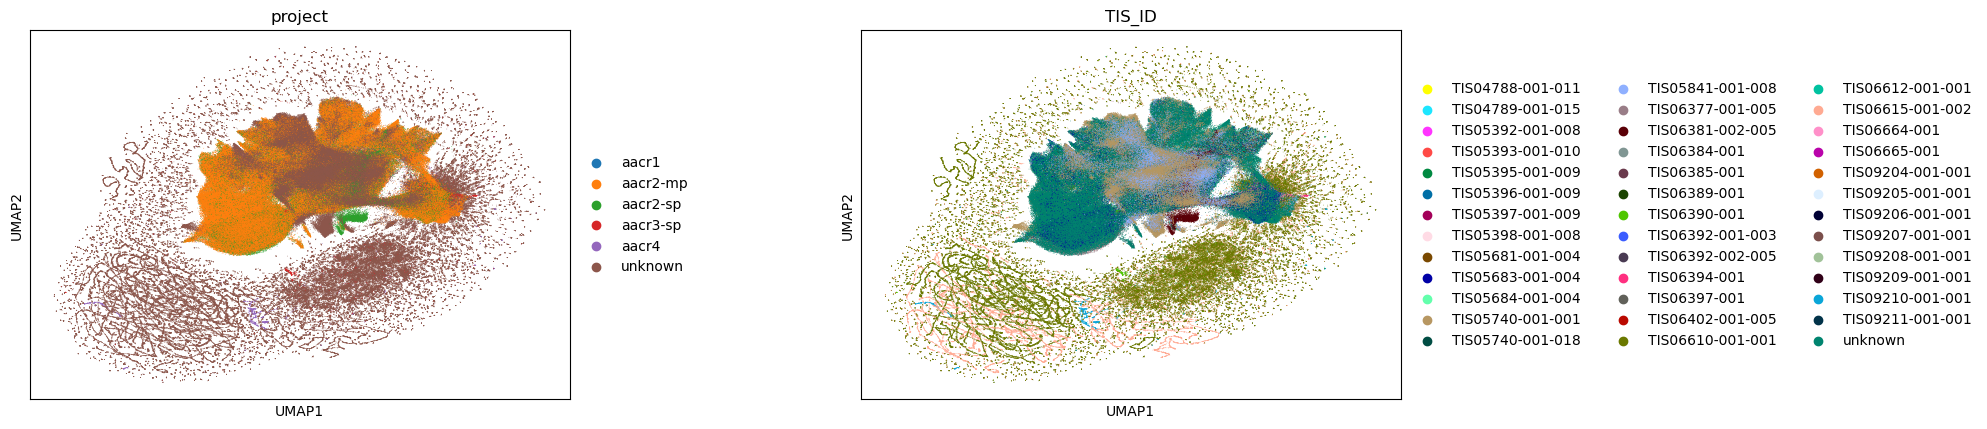

In [17]:
sc.pl.umap(adata_merged, color=['project', 'TIS_ID'], wspace=0.4, size=1)

In [20]:
adata_merged

AnnData object with n_obs × n_vars = 867879 × 18569
    obs: 'source_file', 'TIS_ID', 'project', 'original_barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'project_colors', 'TIS_ID_colors', 'outlier_colors'
    obsm: 'X_pca', 'X_pca_temp', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

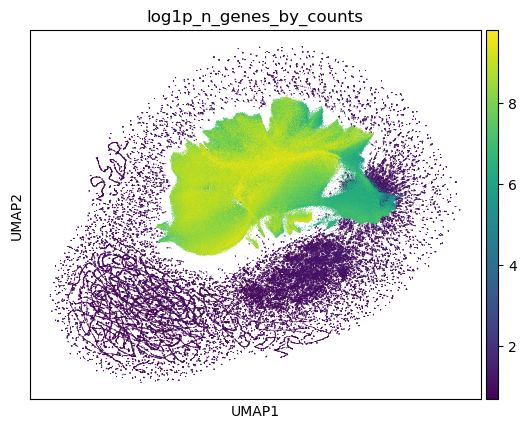

In [23]:
sc.pl.umap(adata_merged, color=['log1p_n_genes_by_counts'], wspace=0.4, size=1)

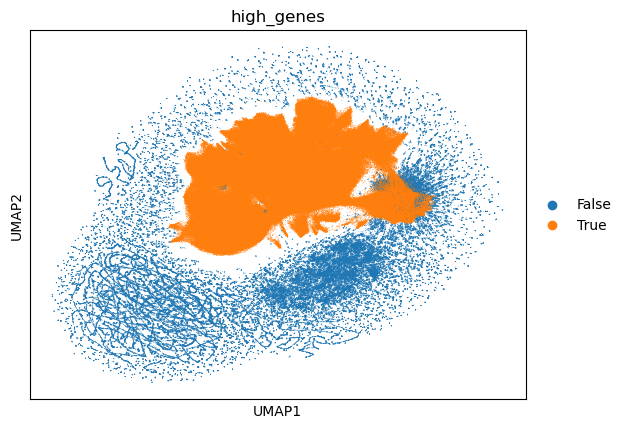

In [24]:
adata_merged.obs['high_genes'] = adata_merged.obs['log1p_n_genes_by_counts'] > 4
sc.pl.umap(adata_merged, color=['high_genes'], wspace=0.4, size=1)

In [25]:
adata_merged.write('files/processed-all-tissdiss-v2.h5ad')
print("Done:", adata_merged)

Done: AnnData object with n_obs × n_vars = 867879 × 18569
    obs: 'source_file', 'TIS_ID', 'project', 'original_barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'high_genes'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'project_colors', 'TIS_ID_colors', 'outlier_colors', 'high_genes_colors'
    obsm: 'X_pca', 'X_pca_temp', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [27]:
subset = adata_merged[adata_merged.obs['high_genes']]

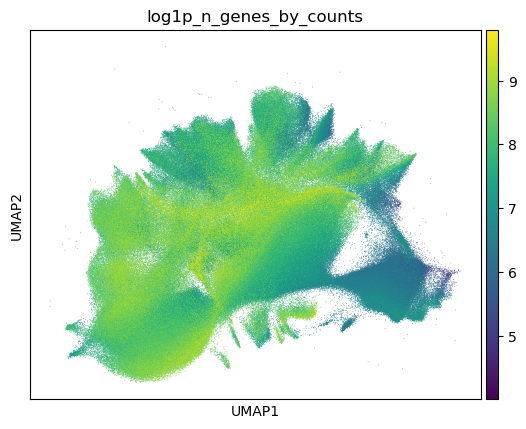

In [28]:
sc.pl.umap(subset, color=['log1p_n_genes_by_counts'], wspace=0.4, size=1)

In [29]:
subset.write('files/processed-subset-tissdiss-v2.h5ad')